In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

random.seed(64)
np.random.seed(64)




In [2]:
def reduce_memory_usage(df):

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != "object":
            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == "int":
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)

            else:
                if (
                    c_min > np.finfo(np.float16).min
                    and c_max < np.finfo(np.float16).max
                ):
                    df[col] = df[col].astype(np.float16)
                elif (
                    c_min > np.finfo(np.float32).min
                    and c_max < np.finfo(np.float32).max
                ):
                    df[col] = df[col].astype(np.float32)
                else:
                    pass
        else:
            df[col] = df[col].astype("category")

    return df




In [3]:
train = pd.read_csv("../input/tabular-playground-series-dec-2021/train.csv")
test = pd.read_csv("../input/tabular-playground-series-dec-2021/test.csv")
train = reduce_memory_usage(train)
test = reduce_memory_usage(test)



In [4]:
print("dimensions of train: {}".format(train.shape))
print("dimensions of test: {}".format(test.shape))



dimensions of train: (3600000, 56)
dimensions of test: (400000, 55)


In [5]:
train.describe()



,Id,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,...,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06
mean,2.000069e+06,2.980147e+03,1.515727e+02,1.510050e+01,2.712761e+02,5.166790e+01,1.766483e+03,2.118390e+02,2.210576e+02,1.408136e+02,...,3.746250e-02,3.785972e-02,1.201639e-02,1.604194e-02,1.068556e-02,1.219861e-02,4.074917e-02,3.924222e-02,3.158944e-02,1.771544e+00
std,1.154820e+06,2.890440e+02,1.099497e+02,8.546351e+00,2.265100e+02,6.822503e+01,1.315661e+03,3.075498e+01,2.223373e+01,4.367894e+01,...,1.898923e-01,1.908569e-01,1.089587e-01,1.256368e-01,1.028172e-01,1.097716e-01,1.977086e-01,1.941708e-01,1.749044e-01,8.940261e-01
min,0.000000e+00,1.773000e+03,-3.300000e+01,-3.000000e+00,-8.200000e+01,-3.170000e+02,-2.870000e+02,-4.000000e+00,4.900000e+01,-5.300000e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,9.997378e+05,2.760000e+03,6.000000e+01,9.000000e+00,1.100000e+02,4.000000e+00,8.220000e+02,1.980000e+02,2.100000e+02,1.150000e+02,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
50%,2.000172e+06,2.966000e+03,1.230000e+02,1.400000e+01,2.130000e+02,3.100000e+01,1.436000e+03,2.180000e+02,2.240000e+02,1.420000e+02,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00
75%,3.000448e+06,3.217000e+03,2.470000e+02,2.000000e+01,3.610000e+02,7.800000e+01,2.365000e+03,2.330000e+02,2.370000e+02,1.690000e+02,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00
max,3.999999e+06,4.383000e+03,4.050000e+02,6.400000e+01,1.602000e+03,6.320000e+02,7.666000e+03,2.970000e+02,2.790000e+02,2.720000e+02,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,7.000000e+00


In [6]:
train.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600000 entries, 0 to 3599999
Data columns (total 56 columns):
 #   Column                              Dtype
---  ------                              -----
 0   Id                                  int32
 1   Elevation                           int16
 2   Aspect                              int16
 3   Slope                               int8 
 4   Horizontal_Distance_To_Hydrology    int16
 5   Vertical_Distance_To_Hydrology      int16
 6   Horizontal_Distance_To_Roadways     int16
 7   Hillshade_9am                       int16
 8   Hillshade_Noon                      int16
 9   Hillshade_3pm                       int16
 10  Horizontal_Distance_To_Fire_Points  int16
 11  Wilderness_Area1                    int8 
 12  Wilderness_Area2                    int8 
 13  Wilderness_Area3                    int8 
 14  Wilderness_Area4                    int8 
 15  Soil_Type1                          int8 
 16  Soil_Type2                          

In [7]:
train.head()



,Id,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,3440475,2634,132,3,166,38,1247,251,210,119,...,0,0,0,0,0,0,0,0,0,2
1,2470812,2769,89,5,633,10,626,177,209,178,...,0,0,0,0,0,0,0,0,0,2
2,536780,2749,46,30,127,239,2569,206,216,144,...,0,0,0,0,0,0,0,0,0,2
3,3115135,2574,155,20,279,1,1932,205,189,199,...,0,0,0,0,0,0,0,0,0,2
4,81861,2779,91,19,523,-2,2976,240,246,105,...,0,0,0,0,0,0,0,0,0,2


In [8]:
print(train.isnull().sum())



Id                                    0
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0


<Axes: xlabel='Cover_Type', ylabel='count'>

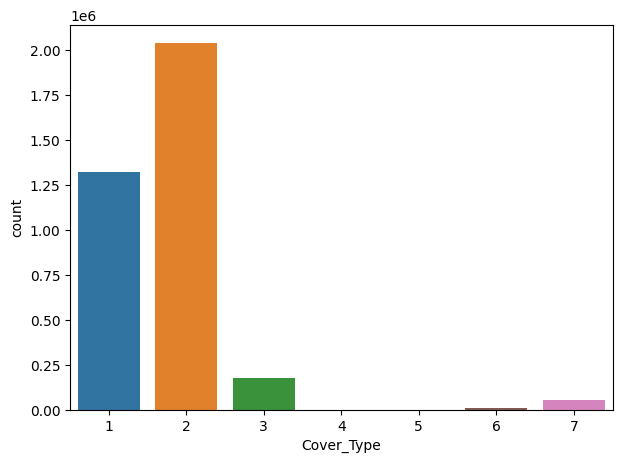

In [9]:
plt.figure(figsize=(7, 5))
sns.countplot(x="Cover_Type", data=train)



In [10]:
train["Cover_Type"].value_counts(ascending=False)



Cover_Type
2    2036254
1    1320866
3     176184
7      56125
6      10237
4        333
5          1
Name: count, dtype: int64

In [11]:
x = train.drop(columns=["Id", "Cover_Type"])
y = train["Cover_Type"]



In [12]:
# Fix: XGBoost multi:softmax expects class labels in [0..num_class-1].
# We encode labels for training and decode predictions back for submission.
le = LabelEncoder()
y_enc = le.fit_transform(y)  # Cover_Type 1..7 -> 0..6

X_train, X_val, y_train, y_val = train_test_split(
    x, y_enc, test_size=0.2, random_state=123, shuffle=True
)



In [13]:
test_df = test.drop(columns=["Id"])



In [14]:
from xgboost import XGBClassifier

# Fix: make GPU optional (Kaggle may run CPU-only depending on settings).
# Keep the same model core logic/hyperparameters; only adjust tree_method/predictor if needed.
use_gpu = False
try:
    import xgboost

    # If build lacks CUDA, gpu_hist will error at fit time; we also protect with a try/except in fit below.
    use_gpu = True
except Exception:
    use_gpu = False

params = {
    "objective": "multi:softmax",
    "eval_metric": "mlogloss",
    "booster": "gbtree",
    "gamma": 0.75,
    "max_depth": 7,
    "alpha": 10,
    "learning_rate": 0.007,
    "n_estimators": 2000,
    "random_state": 64,
}

if use_gpu:
    params.update({"tree_method": "gpu_hist", "predictor": "gpu_predictor"})
else:
    params.update({"tree_method": "hist", "predictor": "auto"})

xgb = XGBClassifier(**params)

try:
    xgb.fit(
        X_train,
        y_train,
        early_stopping_rounds=200,
        eval_set=[(X_val, y_val)],
        verbose=True,
    )
except Exception as e:
    # Final fallback to CPU if GPU configuration fails at runtime.
    params.update({"tree_method": "hist", "predictor": "auto"})
    xgb = XGBClassifier(**params)
    xgb.fit(
        X_train,
        y_train,
        early_stopping_rounds=200,
        eval_set=[(X_val, y_val)],
        verbose=True,
    )



/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [02:17:37] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [02:17:37] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "predictor" } are not used.

  warnings.warn(smsg, UserWarning)


[0]	validation_0-mlogloss:1.92481
[1]	validation_0-mlogloss:1.90420
[2]	validation_0-mlogloss:1.88407
[3]	validation_0-mlogloss:1.86440
[4]	validation_0-mlogloss:1.84514
[5]	validation_0-mlogloss:1.82630
[6]	validation_0-mlogloss:1.80787
[7]	validation_0-mlogloss:1.78978
[8]	validation_0-mlogloss:1.77208
[9]	validation_0-mlogloss:1.75472
[10]	validation_0-mlogloss:1.73771
[11]	validation_0-mlogloss:1.72101
[12]	validation_0-mlogloss:1.70461
[13]	validation_0-mlogloss:1.68854
[14]	validation_0-mlogloss:1.67274
[15]	validation_0-mlogloss:1.65724
[16]	validation_0-mlogloss:1.64200
[17]	validation_0-mlogloss:1.62704
[18]	validation_0-mlogloss:1.61234
[19]	validation_0-mlogloss:1.59787
[20]	validation_0-mlogloss:1.58366
[21]	validation_0-mlogloss:1.56968
[22]	validation_0-mlogloss:1.55592
[23]	validation_0-mlogloss:1.54238
[24]	validation_0-mlogloss:1.52906
[25]	validation_0-mlogloss:1.51595
[26]	validation_0-mlogloss:1.50301
[27]	validation_0-mlogloss:1.49029
[28]	validation_0-mlogloss:1.4

In [15]:
y_pred = xgb.predict(X_val)



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [02:20:37] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [02:20:37] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


In [16]:
from sklearn.metrics import accuracy_score

print("Accuracy Score : ", accuracy_score(y_val, y_pred))



Accuracy Score :  0.9569819444444444


In [17]:
# Predict on test, then decode to original Cover_Type labels 1..7
test_pred_enc = xgb.predict(test_df)
test_pred = le.inverse_transform(test_pred_enc.astype(int))



In [18]:
submission = pd.read_csv(
    "../input/tabular-playground-series-dec-2021/sample_submission.csv"
)
submission["Cover_Type"] = test_pred
submission.to_csv("submission2.csv", index=False)
submission.head()



,Id,Cover_Type
0,814683,1
1,1357371,2
2,2106112,1
3,3483684,1
4,3960754,7


In [19]:
from catboost import CatBoostClassifier

# Keep core approach; make GPU optional to avoid runtime failure.
try:
    model = CatBoostClassifier(
        task_type="GPU", devices="0", verbose=False, random_seed=64
    )
except Exception:
    model = CatBoostClassifier(task_type="CPU", verbose=False, random_seed=64)

model.fit(X_train, y_train)



In [20]:
y_pred1 = model.predict(X_val)



In [21]:
from sklearn.metrics import accuracy_score

print("Accuracy Score : ", accuracy_score(y_val, y_pred1))



Accuracy Score :  0.9605972222222222


In [22]:
# Predict + decode
test_pred1_enc = model.predict(test_df).astype(int).reshape(-1)
test_pred1 = le.inverse_transform(test_pred1_enc)



In [23]:
# Fix: write the correct prediction variable for this model too.
submission = pd.read_csv(
    "../input/tabular-playground-series-dec-2021/sample_submission.csv"
)
submission["Cover_Type"] = test_pred1
submission.to_csv("submission1.csv", index=False)
submission.head()

,Id,Cover_Type
0,814683,1
1,1357371,2
2,2106112,1
3,3483684,1
4,3960754,7
